# In this jupyter notebook file, we will replicate the results reported in the paper : Controllability of Complex networks 

In [92]:
try:
    import networkx  as nx
    import matplotlib.pyplot as plt

except ImportError:
    !pip install networkx matplotlib
    import networkx  as nx
    import matplotlib.pyplot as plt

Following is an utility function that will be used to draw the directed network 

In [93]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_control_graph(G, matched_nodes, matching):
    """
    Plot a directed graph highlighting:
    - matched nodes
    - unmatched/driver nodes
    - maximum-matching edges
    """

    pos = nx.spring_layout(G, seed=42)

    # Recover matching edges in the original directed graph
    matching_edges = [
        (u, v)
        for u, v in G.edges()
        if matching.get((u, "out")) == (v, "in")
    ]

    # Node colors
    node_colors = [
        "lightgreen" if node in matched_nodes else "white"
        for node in G.nodes()
    ]

    # Edge colors
    edge_colors = [
        "purple" if edge in matching_edges else "gray"
        for edge in G.edges()
    ]

    nx.draw(
        G,
        pos,
        with_labels=True,
        arrows=True,
        node_color=node_colors,
        edge_color=edge_colors,
        edgecolors="black",
        node_size=1500,
        width=2,
        font_size=11
    )

    # Legend
    legend_items = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Matched node"),
        Patch(facecolor="white", edgecolor="black", label="Unmatched / Driver node"),
        Line2D([0], [0], color="purple", lw=2, label="Matching edge"),
        Line2D([0], [0], color="gray", lw=2, label="Non-matching edge")
    ]

    plt.legend(handles=legend_items)
    plt.show()

We will generate the Figure 1(b) diagram and we will be using the networkx library for this 

In [94]:
G = nx.DiGraph()

G.add_edges_from([("x1","x2"), ("x2","x3"), ("x3","x4")])



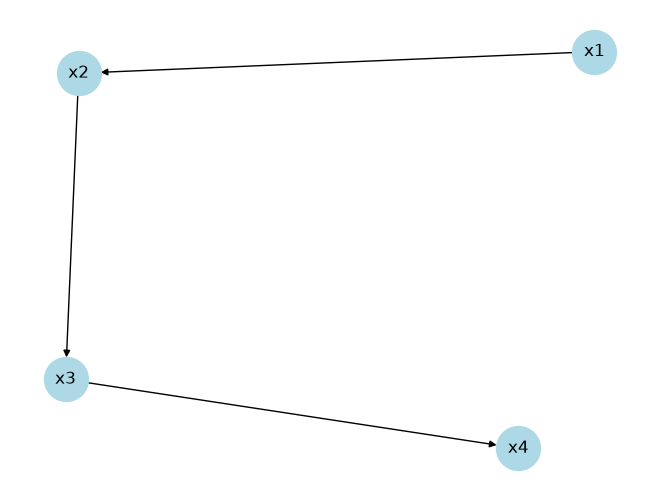

In [65]:
nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
plt.show()

We will now perform maximum matching on this network using bipartite algorithm

In [95]:
# Let's create a bipartite graph from the directed graph G 
# this bipartite graph will be used to determine the maximum matching


B = nx.Graph()

left_nodes = [(node,"out") for node in G.nodes()]
right_nodes = [(node,"in") for node in G.nodes()]

B.add_nodes_from(left_nodes, bipartite=0)  # bipartite=0 is on the left side, the out nodes who sends the edge
B.add_nodes_from(right_nodes, bipartite=1) # bipartite=1 is on the right side, the in nodes who receives the edge

for u,v in G.edges():
    B.add_edge((u,"out"), (v,"in")) # connect left and right according to the directed edges in G

Calculate the maximum matching from the bipartite graph 

In [96]:
matching = nx.algorithms.bipartite.maximum_matching(
    B,
    top_nodes=left_nodes # tells the algorithm which nodes are on the left side of the bipartite graph
)

print(matching)

{('x2', 'out'): ('x3', 'in'), ('x3', 'out'): ('x4', 'in'), ('x1', 'out'): ('x2', 'in'), ('x2', 'in'): ('x1', 'out'), ('x4', 'in'): ('x3', 'out'), ('x3', 'in'): ('x2', 'out')}


In [97]:
matched_nodes = { node for node in G.nodes() if (node,"in") in matching }

unmatched_nodes = set(G.nodes()) - matched_nodes

print("Matched nodes:", matched_nodes)  
print("Unmatched nodes:", unmatched_nodes)

Matched nodes: {'x2', 'x4', 'x3'}
Unmatched nodes: {'x1'}


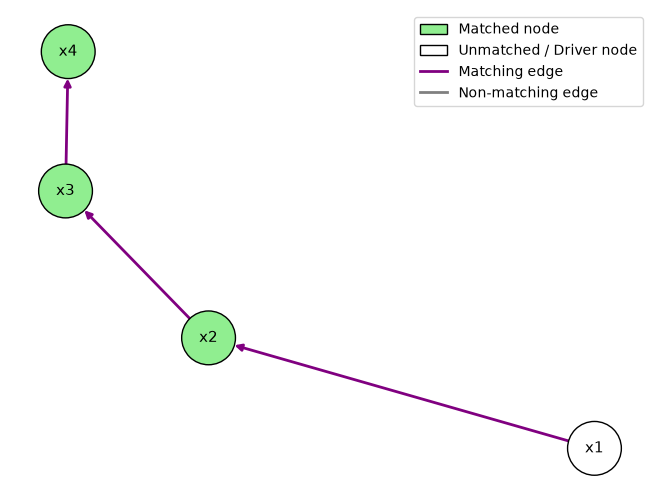

In [98]:
plot_control_graph(G, matched_nodes, matching)

Figure 1e and its corresponding maximum matching

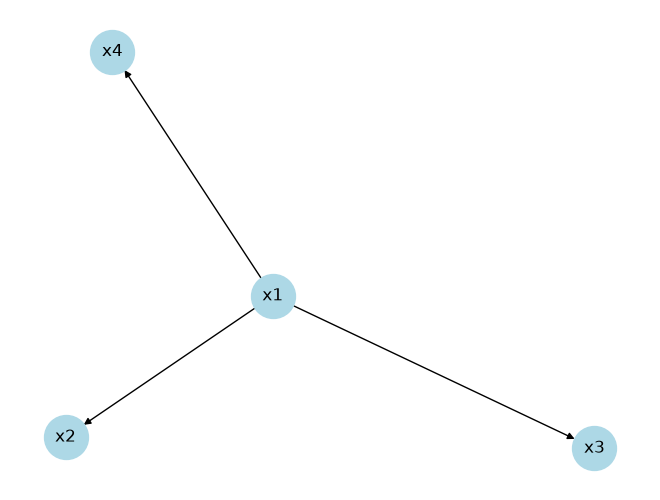

In [99]:
G = nx.DiGraph()

G.add_edges_from([("x1","x2"), ("x1","x3"), ("x1","x4")])
nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
plt.show()


{('x1', 'out'): ('x2', 'in'), ('x2', 'in'): ('x1', 'out')}
Matched nodes: {'x2'}
Unmatched nodes: {'x1', 'x4', 'x3'}


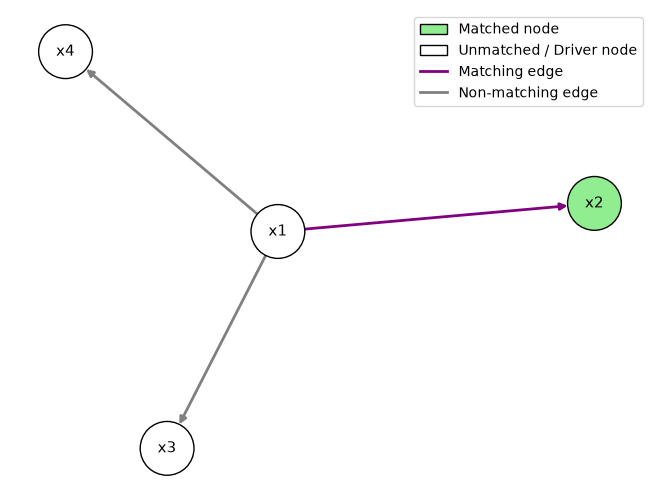

In [100]:
B = nx.Graph()

left_nodes = [(node,"out") for node in G.nodes()]
right_nodes = [(node,"in") for node in G.nodes()]

B.add_nodes_from(left_nodes, bipartite=0)  # bipartite=0 is on the left side, the out nodes who sends the edge
B.add_nodes_from(right_nodes, bipartite=1) # bipartite=1 is on the right side, the in nodes who receives the edge

for u,v in G.edges():
    B.add_edge((u,"out"), (v,"in")) 

matching = nx.algorithms.bipartite.maximum_matching(
    B,
    top_nodes=left_nodes # tells the algorithm which nodes are on the left side of the bipartite graph
)

print(matching)

matched_nodes = { node for node in G.nodes() if (node,"in") in matching }

unmatched_nodes = set(G.nodes()) - matched_nodes

print("Matched nodes:", matched_nodes)  
print("Unmatched nodes:", unmatched_nodes)

plot_control_graph(G, matched_nodes, matching)

We will now plot figure 1h

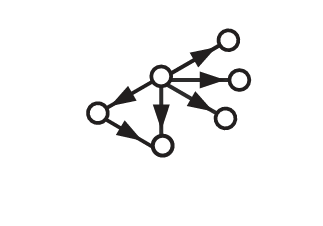

We will generalize and use the following function for the entire works we have been doing so far. this will 
- plot the network
- calculate the maximum matching
- show the network plot with matched nodes after maximum matching

In [101]:
def plot_network_and_matching(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    nx.draw(G, with_labels=True, node_color="lightblue", node_size=1000, arrows=True)
    plt.show()

    B = nx.Graph()
    left_nodes = [(node, "out") for node in G.nodes()]
    right_nodes = [(node, "in") for node in G.nodes()]

    B.add_nodes_from(left_nodes, bipartite=0)
    B.add_nodes_from(right_nodes, bipartite=1)
    B.add_edges_from([((u, "out"), (v, "in")) for u, v in G.edges()])

    matching = nx.algorithms.bipartite.maximum_matching(B, top_nodes=left_nodes)
    matched_nodes = {node for node in G.nodes() if (node, "in") in matching}
    unmatched_nodes = set(G.nodes()) - matched_nodes

    print("Matched nodes:", matched_nodes)
    print("Unmatched nodes:", unmatched_nodes)

    plot_control_graph(G, matched_nodes, matching)

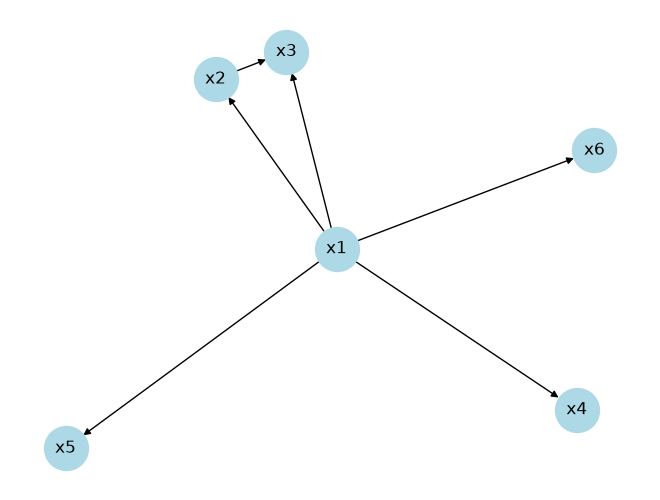

Matched nodes: {'x2', 'x3'}
Unmatched nodes: {'x1', 'x6', 'x4', 'x5'}


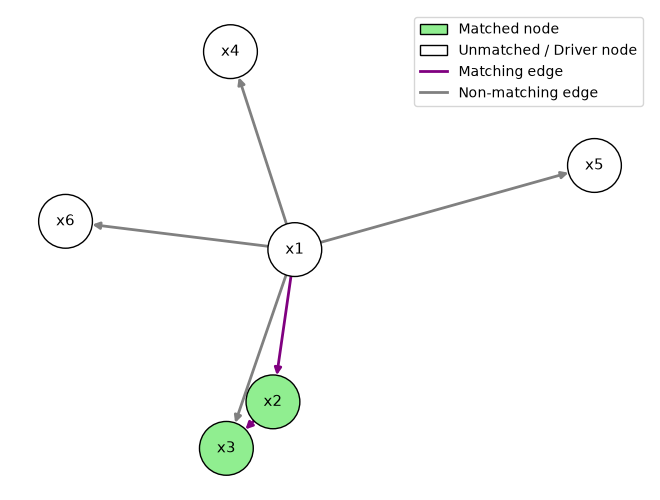

In [102]:
edges = [("x1","x2"),("x1","x3"),("x2","x3"),("x1","x6"),("x1","x5"),('x1','x4')]

plot_network_and_matching(edges)

Let's now find out what are the ordinary link, critical link, and redundant link for this network

According to the paper, 

- **Critical link** is the one that if removed we have to increase the number of driver nodes 
- **redundant link** in all possible maximum matching configuration, it always remains an unmatched link
- **ordinary link** neither critical and nor redundant 

Let's write a function that will just return the matched nodes and  unmatched nodes and driver nodes  and the network object. It will not plot anything, it will take the edges and return the network and important characteristics relevant to this paper.

In [103]:
def get_matching_nodes(edges, nodes=None):
    """
    Given a list of directed edges, this function constructs a directed graph,
    converts it into a bipartite graph, computes the maximum matching, and returns
    a dictionary containing the matched nodes, unmatched nodes, driver nodes,
    original graph, number of driver nodes, matching links, and unmatching links.

    nodes=None means nodes are created from the given edges.
    If nodes are provided, they are added before the edges so isolated nodes
    are also included in the graph.
    """
    G = nx.DiGraph()
    if nodes is not None:
        G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    B = nx.Graph()
    left_nodes = [(node, "out") for node in G.nodes()]
    right_nodes = [(node, "in") for node in G.nodes()]

    B.add_nodes_from(left_nodes, bipartite=0)
    B.add_nodes_from(right_nodes, bipartite=1)
    B.add_edges_from([((u, "out"), (v, "in")) for u, v in G.edges()])

    matching = nx.algorithms.bipartite.maximum_matching(B, top_nodes=left_nodes)
    matched_nodes = {node for node in G.nodes() if (node, "in") in matching}
    unmatched_nodes = set(G.nodes()) - matched_nodes
    driver_nodes = unmatched_nodes.copy()

    matching_links = {
        (u, v) for u, v in G.edges()
        if matching.get((u, "out")) == (v, "in")
    }
    unmatching_links = set(G.edges()) - matching_links

    return {
        "G": G,
        "matched_nodes": matched_nodes,
        "unmatched_nodes": unmatched_nodes,
        "driver_nodes": driver_nodes,
        "N_D": max(1, len(unmatched_nodes)) if G.number_of_nodes() else 0,
        "matching_links": matching_links,
        "unmatching_links": unmatching_links,
    }

In [104]:
def critical_link(edges, nodes=None):
    """
    Given a list of directed edges, this function identifies critical links
    in the directed graph. A critical link is defined as an edge whose removal
    decreases the size of the maximum matching.

    nodes=None means nodes are created from the given edges.
    If nodes are provided, isolated nodes are also included in the graph.
    All original nodes are preserved when testing each edge removal.

    It returns a dictionary containing the original graph, matched nodes,
    unmatched nodes, driver nodes, number of driver nodes, matching links,
    unmatching links, and critical links.
    """
    network = get_matching_nodes(edges, nodes)
    G = network["G"]
    matching_links = network["matching_links"]
    critical_links = set()

    for edge in G.edges():
        remaining_edges = set(G.edges()) - {edge}
        result = get_matching_nodes(remaining_edges, nodes=G.nodes())
        new_matching_links = result["matching_links"]

        if len(new_matching_links) < len(matching_links):
            critical_links.add(edge)

    return {**network, "critical_links": critical_links}


Now a function that will return the redundant links 

In [107]:
def redundant_link(edges, nodes=None):
    """
    A redundant link never appears in any maximum matching.
    We force each edge (u, v) to be included in a matching configuration
    by keeping it and removing every other edge with the same starting
    node u or the same ending node v.
    The kept edge is automatically included in the maximum matching,
    
    If this matching has fewer links than the original maximum,
    then that edge is redundant.

    nodes=None means nodes are created from the given edges.
    If nodes are provided, isolated nodes are also included in the graph.
    """
    network = get_matching_nodes(edges, nodes)
    G = network["G"]
    matching_links = network["matching_links"]
    redundant_links = set()

    for u, v in G.edges():
        remaining_edges = [
            (a, b) for a, b in G.edges()
            if (a, b) == (u, v) or (a != u and b != v)
        ]
        result = get_matching_nodes(remaining_edges, nodes=G.nodes())
        forced_size = len(result["matching_links"])

        if forced_size < len(matching_links):
            redundant_links.add((u, v))

    return {**network, "redundant_links": redundant_links}


In [108]:
def ordinary_link(edges, nodes=None):
    """
    An ordinary link is neither critical nor redundant.
    We use the critical and redundant link functions and return the same
    network information, together with all three link categories.
    """
    result = critical_link(edges, nodes)
    redundant_links = redundant_link(edges, nodes)["redundant_links"]
    ordinary_links = set(result["G"].edges()) - result["critical_links"] - redundant_links
    return {**result, "redundant_links": redundant_links, "ordinary_links": ordinary_links}


Now the following is a function that use all the above functions to find out the network characteristics and plots the links and matching nodes and driver nodes etc

In [109]:
def plot_complete_network_graph(edges):
    """
    Given directed edges, calculate matching and link categories, then plot:
    green matched nodes, white unmatched nodes, purple matching links,
    red critical links, green redundant links, and gray ordinary links.
    """
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    result = ordinary_link(list(edges))
    G = result["G"]
    pos = nx.spring_layout(G, seed=42)

    node_colors = [
        "lightgreen" if node in result["matched_nodes"] else "white"
        for node in G.nodes()
    ]
    matching_colors = [
        "purple" if edge in result["matching_links"] else "black"
        for edge in G.edges()
    ]
    category_colors = [
        "red" if edge in result["critical_links"] else
        "green" if edge in result["redundant_links"] else "gray"
        for edge in G.edges()
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, colors, title in zip(
        axes,
        [matching_colors, category_colors],
        ["Maximum matching", "Link categories"]
    ):
        nx.draw(
            G, pos, ax=ax, with_labels=True, arrows=True,
            node_color=node_colors, edgecolors="black",
            edge_color=colors, node_size=1200, arrowsize=20, width=2
        )
        ax.set_title(title)

    node_legend = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Matched node"),
        Patch(facecolor="white", edgecolor="black", label="Unmatched node"),
    ]
    axes[0].legend(handles=node_legend + [
        Line2D([0], [0], color="purple", lw=2, label="Matching link"),
        Line2D([0], [0], color="black", lw=2, label="Non-matching link"),
    ], loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)

    axes[1].legend(handles=node_legend + [
        Line2D([0], [0], color="red", lw=2, label="Critical link"),
        Line2D([0], [0], color="green", lw=2, label="Redundant link"),
        Line2D([0], [0], color="gray", lw=2, label="Ordinary link"),
    ], loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)

    plt.tight_layout()
    plt.show()

Let's plot figure 1d in the paper 

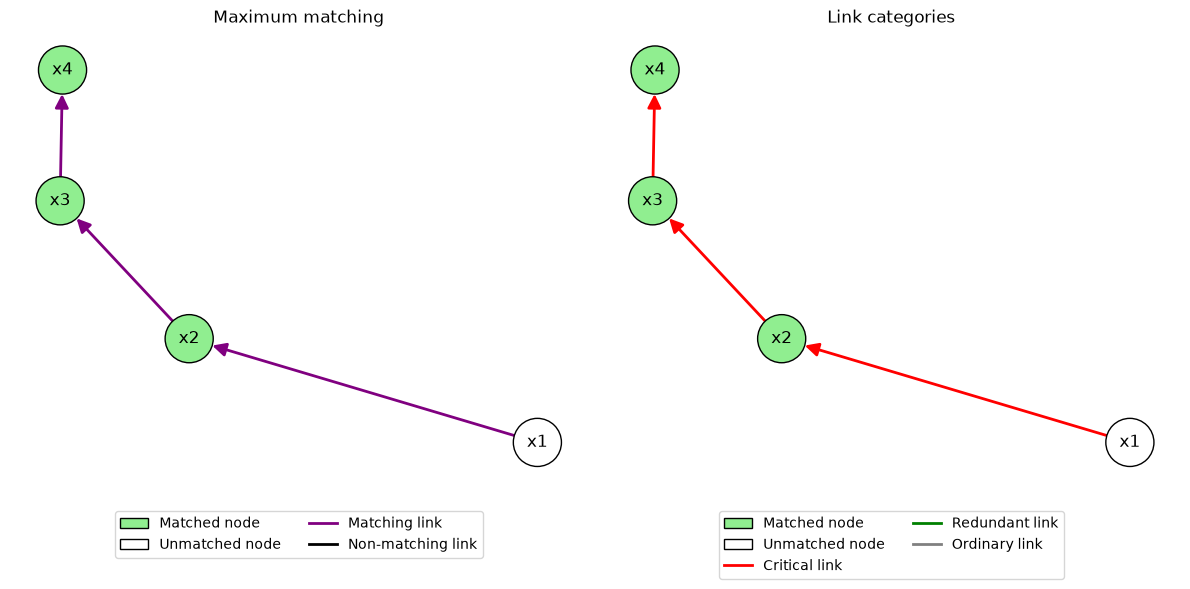

In [110]:
edges =[("x1","x2"), ("x2","x3"), ("x3","x4")]

plot_complete_network_graph(edges)

Figure 1j :

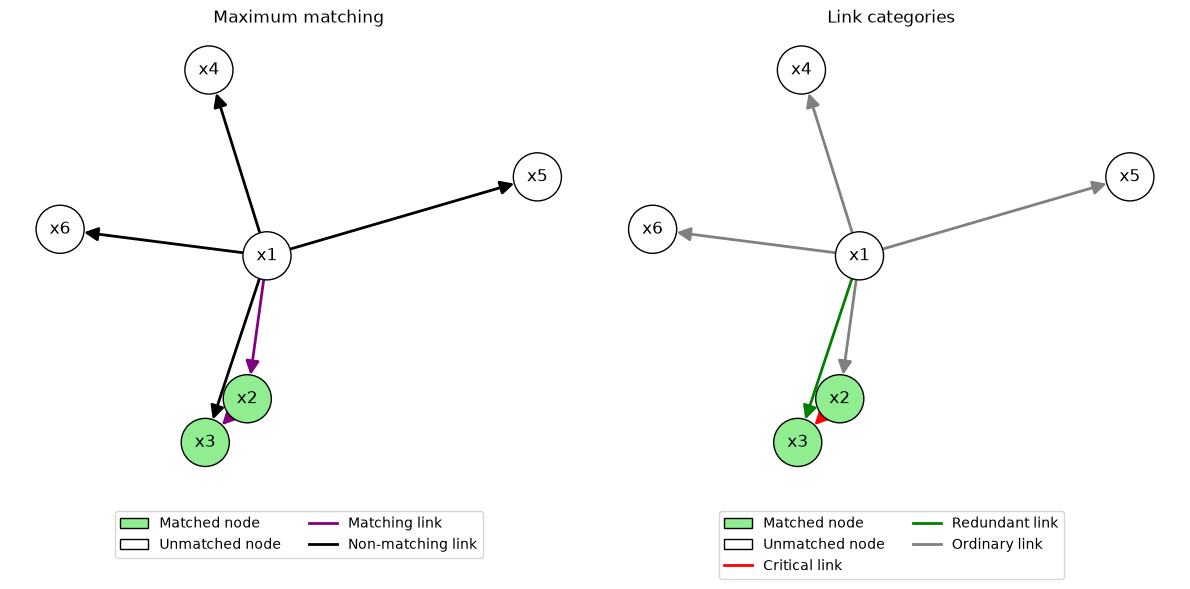

In [111]:
edges = [("x1","x2"),("x1","x3"),("x2","x3"),("x1","x6"),("x1","x5"),('x1','x4')]
plot_complete_network_graph(edges)

### Now we will simulate ER Network and find driver nodes for ER network and reproduce the results shown in the figure 2 

Fig 2a

In [138]:
def erdos_renyi_network(N, k_avg):
    """Generate a directed Erdos-Renyi network with expected average total degree k_avg."""
    p = k_avg / (2 * (N - 1))

    # a faster algorithmn 
    return nx.fast_gnp_random_graph(N, p, directed=True)

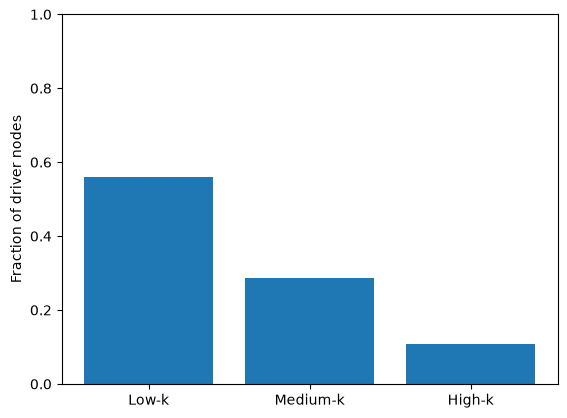

In [113]:
er_network = erdos_renyi_network(N= 10**4, k_avg = 3)

# consider the isolated nodes as well, so we pass the nodes to the function
results=get_matching_nodes(edges = er_network.edges(), nodes = er_network.nodes())
driver_nodes = results["driver_nodes"]

# sort the nodes by their degree 
nodes = sorted(er_network.nodes(), key=lambda node: er_network.degree(node))

size = len(nodes)//3
low_k = nodes[:size]
medium_k = nodes[size:2*size]
high_k = nodes[2*size:]

# find the fraction of driver nodes in each group
fractions = []
for group  in [low_k, medium_k, high_k]:
   count = 0 
   for node in group :
      if node in driver_nodes:
         count += 1
   fractions.append(count/len(group))

plt.bar(["Low-k", "Medium-k", "High-k"], fractions)
plt.ylabel("Fraction of driver nodes")
plt.ylim(0, 1)
plt.show()

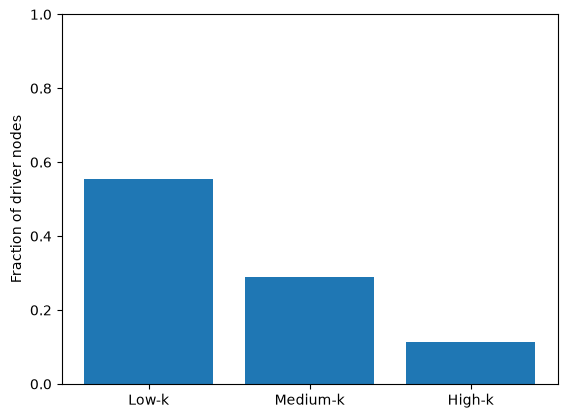

In [91]:
#let's now carry out this same experiment for 100s of iterations and average value : 

import numpy as np
iterations = 100

fractions = np.array([0,0,0])
for iteration in range(iterations):
    er_network = erdos_renyi_network(N= 10**4, k_avg = 3)

    # consider the isolated nodes as well, so we pass the nodes to the function
    results=get_matching_nodes(edges = er_network.edges(), nodes = er_network.nodes())
    driver_nodes = results["driver_nodes"]
    # sort the nodes by their degree 
    nodes = sorted(er_network.nodes(), key=lambda node: er_network.degree(node))

    size = len(nodes)//3
    low_k = nodes[:size]
    medium_k = nodes[size:2*size]
    high_k = nodes[2*size:]

    # find the fraction of driver nodes in each group
    fraction_one_iteration = []
    for group  in [low_k, medium_k, high_k]:
        count = 0 
        for node in group :
            if node in driver_nodes:
                count += 1
        fraction_one_iteration.append(count/len(group))
    fractions = fractions + np.array(fraction_one_iteration)

# Average the fractions over all iterations
average_fractions = fractions / iterations

plt.bar(["Low-k", "Medium-k", "High-k"], average_fractions) 
plt.ylabel("Fraction of driver nodes")
plt.ylim(0, 1)
plt.show()

Fig 2b

In [119]:
try : 
    import igraph as ig
except ImportError:
    !pip install python-igraph
    import igraph as ig

In [120]:
def generate_scale_free_network(N, k_avg, gamma=3):
    """
    Generate a directed scale-free network using igraph's static model,
    then return it as a NetworkX directed graph.
    k_avg is the average total degree (in-degree + out-degree).
    gamma > 2 controls the exponent for both degree distributions.
    """
    import igraph as ig

    if N < 2 or gamma <= 2 or not 0 <= k_avg <= 2 * (N - 1):
        raise ValueError("Use N >= 2, gamma > 2, and 0 <= k_avg <= 2*(N-1).")

    network = ig.Graph.Static_Power_Law(
        n=N,
        m=round(N * k_avg / 2),
        exponent_out=gamma,
        exponent_in=gamma,
        allowed_edge_types="simple",
        finite_size_correction=False
    )

    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    G.add_edges_from(network.get_edgelist())
    return G

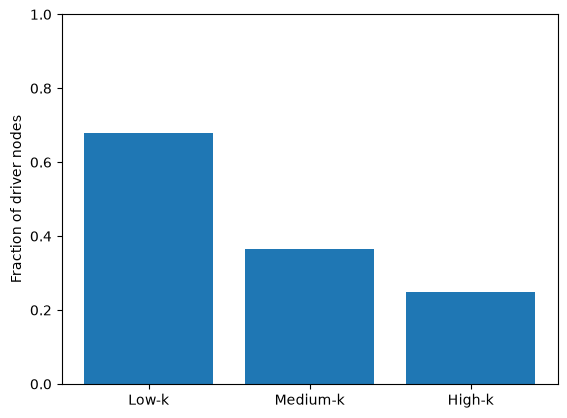

In [121]:
#let's now carry out this same experiment for 100s of iterations and average value : 
# we can use the simulation written for Erdos Renyi for the  Scale free network as well 

import numpy as np
iterations = 100

fractions = np.array([0,0,0])
for iteration in range(iterations):
    scale_free_network = generate_scale_free_network(N= 10**4, k_avg = 3)

    # consider the isolated nodes as well, so we pass the nodes to the function
    results=get_matching_nodes(edges = scale_free_network.edges(), nodes = scale_free_network.nodes())
    driver_nodes = results["driver_nodes"]
    # sort the nodes by their degree 
    nodes = sorted(scale_free_network.nodes(), key=lambda node: scale_free_network.degree(node))

    size = len(nodes)//3
    low_k = nodes[:size]
    medium_k = nodes[size:2*size]
    high_k = nodes[2*size:]

    # find the fraction of driver nodes in each group
    fraction_one_iteration = []
    for group  in [low_k, medium_k, high_k]:
        count = 0 
        for node in group :
            if node in driver_nodes:
                count += 1
        fraction_one_iteration.append(count/len(group))
    fractions = fractions + np.array(fraction_one_iteration)

# Average the fractions over all iterations
average_fractions = fractions / iterations

plt.bar(["Low-k", "Medium-k", "High-k"], average_fractions) 
plt.ylabel("Fraction of driver nodes")
plt.ylim(0, 1)
plt.show()

### Now the Plots in figure 3 will be implemented

figure 3 d

This graph is a $n_D$ vs $<k>$ graph for both Erdos-Renyi and Scale-Free Network. For Scale Free network a number of different $\gamma$ was considered

Only maximum matching simulation and analytically derived equation is considered here. The cavity approach is ignored. 


We will use functions that were declared earlier to generate the each of the networks and fraction of driver nodes and here we will write the codes that plots the results 

In [134]:
with plt.ioff():
    fig, ax = plt.subplots(figsize=(8, 5))

In [135]:
try :
    import joblib
except ImportError:
    !pip install joblib
    import joblib

In [136]:
from joblib import Parallel, delayed

def get_driver_fraction(k_avg, gamma):
    network = generate_scale_free_network(10**4, k_avg, gamma)
    results = get_matching_nodes(network.edges(), nodes=network.nodes())
    return results["N_D"] / 10**4

k_avg_values = np.linspace(10, 50, 100)

for gamma, color in zip([2.2, 2.5, 3.0, 4.0], colors):
    n_D_values = Parallel(n_jobs=4, verbose=10)(
        delayed(get_driver_fraction)(k_avg, gamma)
        for k_avg in k_avg_values
    )

    ax.plot(k_avg_values, n_D_values, color=color, marker="o",
            markerfacecolor="none", linestyle="none",
            label=rf"SF $\gamma={gamma}$, $N=10^4$")

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    3.5s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    4.3s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   14.0s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   20.5s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   24.5s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   31.9s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   41.3s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:   54.3s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  1.6min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    4.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    8.4s
[Parallel(n_jobs=4)]: Done  17 tasks      | elap

In [ ]:
# let's simulate erdos-renyi networks with N = 10^5 


k_avg_values = np.linspace(10, 50, 100)

# ER large-degree analytical approximation
ax.plot(k_avg_values, np.exp(-k_avg_values / 2),
        color="black", label=r"ER $N=\infty$")

# ER numerical results using your existing generator
N = 10**5
n_D_values = []

for k_avg in k_avg_values:
    print(k_avg)
    network = erdos_renyi_network(N, k_avg)
    results = get_matching_nodes(network.edges(), nodes=network.nodes())
    n_D_values.append(results["N_D"] / N)

ax.plot(k_avg_values, n_D_values, color="black", marker="o",
        markerfacecolor="none", linestyle="none",
        label=r"ER $N=10^5$")

10.0
10.404040404040405
10.808080808080808
11.212121212121213
11.616161616161616
12.02020202020202
12.424242424242424
12.828282828282829
13.232323232323232
13.636363636363637


In [ ]:
k_avg_values = np.linspace(10, 50, 100)

# Scale-free analytical approximations
colors = ["red", "green", "blue", "orange"]

for gamma, color in zip([2.2, 2.5, 3.0, 4.0], colors):
    n_D_values = np.exp(
        -0.5 * (1 - 1 / (gamma - 1)) * k_avg_values
    )
    ax.plot(k_avg_values, n_D_values, color=color, linestyle="-",
            label=rf"SF $\gamma={gamma}$, analytical approximation")

# Erdos–Renyi analytical approximation
n_D_values = np.exp(-k_avg_values / 2)

ax.plot(k_avg_values, n_D_values, color="black", linestyle="-",
        label="ER, analytical approximation")